<a href="https://colab.research.google.com/github/Guru-CS/Global-Aviation-Incidents-Research/blob/main/GlobalAviationIncidentsResearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y fastai fastcore fasttransform torch torchvision torchaudio

!pip install \
    fastai==2.7.18 \
    fastcore==1.5.29 \
    torch==2.5.1 \
    torchvision==0.20.1

Found existing installation: fastai 2.8.7
Uninstalling fastai-2.8.7:
  Successfully uninstalled fastai-2.8.7
Found existing installation: fastcore 2.0.5
Uninstalling fastcore-2.0.5:
  Successfully uninstalled fastcore-2.0.5
Found existing installation: fasttransform 0.0.2
Uninstalling fasttransform-0.0.2:
  Successfully uninstalled fasttransform-0.0.2
Found existing installation: torch 2.11.0+cpu
Uninstalling torch-2.11.0+cpu:
  Successfully uninstalled torch-2.11.0+cpu
Found existing installation: torchvision 0.26.0+cpu
Uninstalling torchvision-0.26.0+cpu:
  Successfully uninstalled torchvision-0.26.0+cpu
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu
INFO: pip is looking at multiple versions of fastprogress to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.5/234.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5035 entries, 0 to 5034
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Year                   5035 non-null   int64 
 1   Quarter                5035 non-null   object
 2   Month                  5035 non-null   object
 3   Day                    5035 non-null   int64 
 4   Country/Region         4805 non-null   object
 5   Aircraft Manufacturer  5035 non-null   object
 6   Aircraft               5035 non-null   object
 7   Location               5035 non-null   object
 8   Operator               4801 non-null   object
 9   Ground                 5035 non-null   int64 
 10  Fatalities (air)       5035 non-null   int64 
 11  Aboard                 5035 non-null   int64 
dtypes: int64(5), object(7)
memory usage: 472.2+ KB


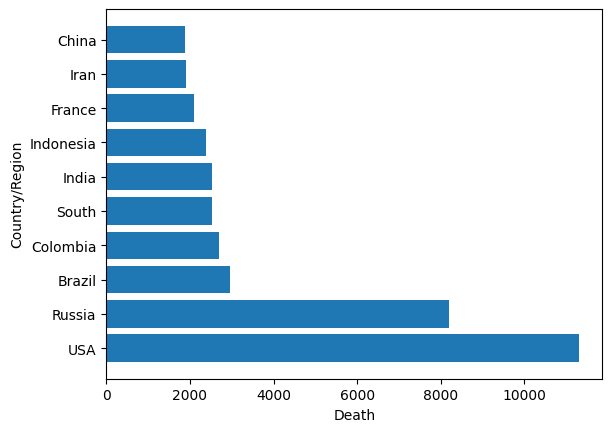

21
25
46


/tmp/ipykernel_6297/713817759.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


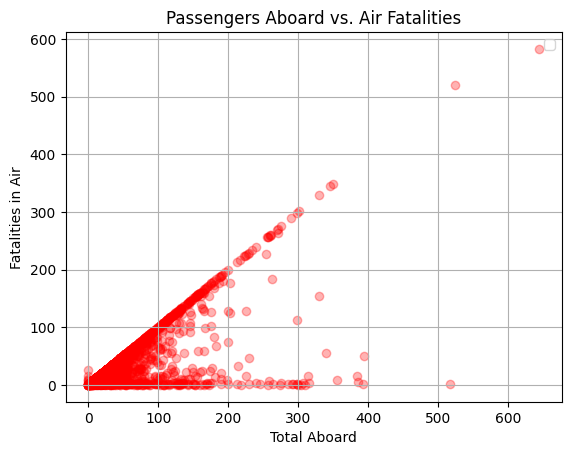

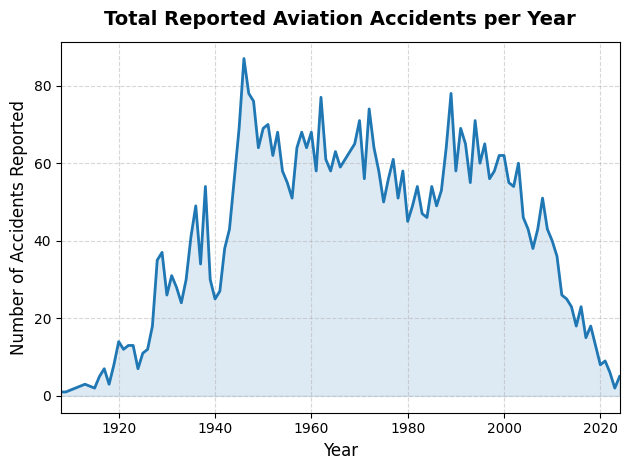

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.43      0.47       347
           1       0.69      0.75      0.72       586

    accuracy                           0.63       933
   macro avg       0.60      0.59      0.59       933
weighted avg       0.62      0.63      0.63       933



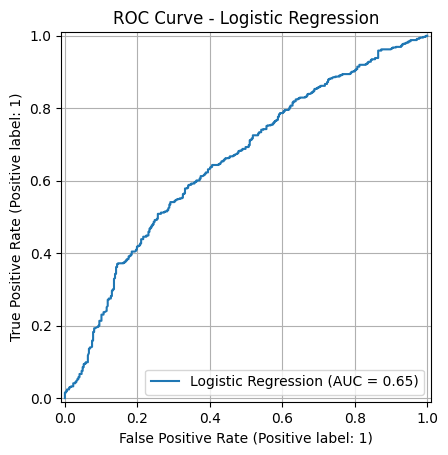

torch.Size([3730, 5])


AttributeError: 'list' object has no attribute 'starmap'

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
data= pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Global%20Aviation%20Incidents/aircrashesFullDataUpdated_2024.csv")
data.info()
data.head()
data['Aircraft Manufacturer'] = data['Aircraft Manufacturer'].astype(str).str.strip()
data['Aircraft'] = data['Aircraft'].astype(str).str.strip()
data['Manufacturer_Grouped'] = data['Aircraft Manufacturer'].where(
    data.groupby('Aircraft Manufacturer')['Aircraft Manufacturer'].transform('count') > 15,
    'Other'
)
data['Aircraft_Grouped'] = data['Aircraft'].where(
    data.groupby('Aircraft')['Aircraft'].transform('count') > 15,
    'Other'
)
data['Aircraft_Operator'] = data['Operator'].where(
    data.groupby('Operator')['Operator'].transform('count') > 15,
    'Other'
)
# Did not type all the location mapping used AI and there are still countries i could add
location_mapping = {
'alabama': 'USA',
    'alaska': 'USA',
    'arizona': 'USA',
    'arkansas': 'USA',
    'california': 'USA',
    'colorado': 'USA',
    'connecticut': 'USA',
    'delaware': 'USA',
    'florida': 'USA',
    'georgia': 'USA',
    'hawaii': 'USA',
    'idaho': 'USA',
    'illinois': 'USA',
    'indiana': 'USA',
    'iowa': 'USA',
    'kansas': 'USA',
    'kentucky': 'USA',
    'louisiana': 'USA',
    'maine': 'USA',
    'maryland': 'USA',
    'massachusetts': 'USA',
    'michigan': 'USA',
    'minnesota': 'USA',
    'mississippi': 'USA',
    'missouri': 'USA',
    'montana': 'USA',
    'nebraska': 'USA',
    'nevada': 'USA',
    'new hampshire': 'USA',
    'new jersey': 'USA',
    'new mexico': 'USA',
    'new york': 'USA',
    'north carolina': 'USA',
    'north dakota': 'USA',
    'ohio': 'USA',
    'oklahoma': 'USA',
    'oregon': 'USA',
    'pennsylvania': 'USA',
    'rhode island': 'USA',
    'south carolina': 'USA',
    'south dakota': 'USA',
    'tennessee': 'USA',
    'texas': 'USA',
    'utah': 'USA',
    'vermont': 'USA',
    'virginia': 'USA',
    'washington': 'USA',
    'west virginia': 'USA',
    'wisconsin': 'USA',
    'wyoming': 'USA'
}
for keyword, clean_name in location_mapping.items():
    mask = data['Country/Region'].str.contains(keyword, case=False, na=False)
    data.loc[mask, 'Country/Region'] = clean_name
filtered_df=data.drop_duplicates()
filtered_df = filtered_df[filtered_df['Country/Region'].str.strip().str.lower() != 'new']
#filtered_df = filtered_df[(filtered_df['Fatalities (air)']>0)|(filtered_df['Ground']>0)] Improved Accuracy and small improvements in ft-score, precision, and recall
filtered_df["Total Fatalities"]=filtered_df['Fatalities (air)'] + filtered_df['Ground']
plt.xlabel("Death")
plt.ylabel("Country/Region")
top_locations = (filtered_df.groupby("Country/Region")["Total Fatalities"].sum().sort_values(ascending=False).head(10))
plt.barh(top_locations.index, top_locations.values)
plt.show()
print(filtered_df['Aircraft_Grouped'].nunique())
print(filtered_df['Aircraft_Operator'].nunique())
print(filtered_df['Manufacturer_Grouped'].nunique())
filtered_df.head(50)
plt.scatter(filtered_df['Aboard'], filtered_df['Fatalities (air)'], alpha=0.3, color='red')
plt.title('Passengers Aboard vs. Air Fatalities')
plt.xlabel('Total Aboard')
plt.ylabel('Fatalities in Air')
plt.legend()
plt.grid(True)
plt.show()
accidents_per_year = filtered_df.groupby('Year').size()
plt.plot(accidents_per_year.index, accidents_per_year.values, color='#1f77b4', linewidth=2, label='Accidents Reported')
plt.fill_between(accidents_per_year.index, accidents_per_year.values, color='#1f77b4', alpha=0.15)
plt.title('Total Reported Aviation Accidents per Year', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Accidents Reported', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(accidents_per_year.index.min(), accidents_per_year.index.max())

plt.tight_layout()
plt.show()
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import TargetEncoder
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.datasets import *
filtered_df['Completely_Fatal'] = (
    filtered_df['Fatalities (air)'] >= filtered_df['Aboard']
).astype(int)

x = filtered_df[['Manufacturer_Grouped', 'Aircraft_Grouped', 'Aircraft_Operator','Country/Region','Aboard']].copy()
y = filtered_df['Completely_Fatal'].copy()
categorical_cols = ['Manufacturer_Grouped', 'Aircraft_Grouped', 'Aircraft_Operator', 'Country/Region']
x = x.dropna()
y = y.loc[x.index]
#x_encoded = pd.get_dummies(x, columns=categorical_cols, drop_first=True) One-Hot ordinal encoding
#learn target encoding
encoder = TargetEncoder(smooth="auto", cv=5)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
x_train_encoded = x_train.copy()
x_train_encoded[categorical_cols] = encoder.fit_transform(x_train[categorical_cols], y_train)
x_test_encoded = x_test.copy()
x_test_encoded[categorical_cols] = encoder.transform(x_test[categorical_cols])
model = LogisticRegression()
model.fit(x_train_encoded, y_train)
y_pred = model.predict(x_test_encoded)

print("Classification Report")
print(classification_report(y_test, y_pred))
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
RocCurveDisplay.from_estimator(
    estimator=model,
    X=x_test_encoded,
    y=y_test,
    name="Logistic Regression",
)
plt.title("ROC Curve - Logistic Regression")
plt.grid(True)
plt.show()
!pip --quiet install torchview
!pip --quiet install torch
!pip --quiet install graphviz
!pip --quiet install fastai

import torch
import torch.nn as nn
from torchview import draw_graph
from fastai.tabular.all import *
import matplotlib.pyplot as plt
import numpy as np


x_train = torch.tensor(x_train_encoded.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

x_valid = torch.tensor(x_test_encoded.values, dtype=torch.float32)
y_valid = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_ds = list(zip(x_train, y_train))
valid_ds = list(zip(x_valid, y_valid))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=64, shuffle=True)

dls = DataLoaders(train_dl, valid_dl)
print(x_train.shape)
model = nn.Sequential(
    nn.Linear(5, 16),
    nn.ReLU(),
    nn.Linear(16, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
)

loss_func = nn.BCEWithLogitsLoss()
learn = Learner(dls, model, loss_func=loss_func, metrics=[accuracy])
learn.fit(n_epoch=10, lr=0.001)
valid_preds, valid_targets = learn.get_preds()
valid_preds_binary = (torch.sigmoid(valid_preds) > 0.5).float()
correct = (valid_preds_binary == valid_targets).float().mean()
print("Validation Accuracy:", correct.item())
print(f"The model predicted correctly {correct*100:.1f}% of the time.")